# Preprocessing

Load data, compute AL score (baseline + longitudinal), build analysis dataset.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


## 1. Load data and filter out rows with NA sleep quality

In [66]:
df = pd.read_csv("swan_long_uncensored_clean_v1.csv")

print(df.shape)
print(df["VISIT"].value_counts().sort_index())
print(df["SWANID"].nunique())
df.head()


C:\Users\gerga\AppData\Local\Temp\ipykernel_23224\2916109081.py:1: DtypeWarning: Columns (261,263,265,267,341,346,557,924,929,931,933,957,958,960,961,963,964,973,975,976,988,989,991,992,994,995,997,998,1000,1001,1003,1004,1006,1007,1009,1010,1012,1013,1015,1016,1018,1019,1021,1022,1033,1034,1035,1049,1113,1114,1137,1151,1152,1160,1164,1176,1178,1180,1182,1189,1201,1202,1229,1315,1317,1382,1474,1497,1531,1543,1555,1567,1579,1591,1603,1615,1627,1639,1651,1663,1675,1687,1698,1710,1722,1734,1746,1758,1770,1772,1783,1821,1833,1835,1846,1848,1859,1893,1919,1921,1922,2086,2089) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("swan_long_uncensored_clean_v1.csv")


(28789, 2106)
VISIT
0     3302
1     2881
2     2748
3     2709
4     2679
5     2617
6     2448
7     2413
8     2278
9     2469
10    2245
Name: count, dtype: int64
3302


,SWANID,VISIT,INTDAY,AGE,PREGNAN,PREVBLO,ALCHL24,EATDRIN,STRTPER,BLDRWAT,...,SALADDR,DRKBEER,FLGHRMV,OSTN1MO1,OSTN1MO2,FLGCOG,SBP,DBP,WHR,sleep_quality
0,10005,0,0.0,48.0,1.0,NaN,1.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,112.666667,80.000000,0.709677,3.0
1,10046,0,0.0,52.0,1.0,NaN,1.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,115.333333,63.333333,0.920398,3.0
2,10056,0,0.0,51.0,1.0,1.0,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,91.333333,63.333333,0.639394,2.0
3,10092,0,0.0,45.0,1.0,NaN,2.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,106.000000,70.000000,0.816624,2.0
4,10126,0,0.0,48.0,1.0,NaN,1.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,99.333333,74.666667,0.819048,2.0


In [67]:
df = df[df["sleep_quality"].notna()].copy()  ##Actual Filtering
print("After sleep-quality filter:", df.shape)
print(df["VISIT"].value_counts().sort_index())
print(df["SWANID"].nunique())


After sleep-quality filter: (26405, 2106)
VISIT
0     3287
1     2856
2     2691
3     2595
4     2520
5     2412
6     2170
7     2239
8     1543
9     2016
10    2076
Name: count, dtype: int64
3299


## 2. Missingness overview

In [68]:
df.isna().mean().sort_values(ascending=False)  ##Missingness by variable


BOTHOVR          1.0
SINGVTN          1.0
HCRMYS           1.0
BCPYS            1.0
LSTURI2          1.0
                ... 
VISIT            0.0
RACE             0.0
HPSCTIM          0.0
SPSCTIM          0.0
sleep_quality    0.0
Length: 2106, dtype: float64

## 3. Initial descriptives

In [69]:
print(df["sleep_quality"].value_counts(normalize=True).sort_index())
print()
print(df["sleep_quality"].describe())
print()
print(df["DHAS"].describe())


sleep_quality
1.0    0.192615
2.0    0.589888
3.0    0.179474
4.0    0.038023
Name: proportion, dtype: float64

count    26405.000000
mean         2.062905
std          0.721279
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: sleep_quality, dtype: float64

count    23956.000000
mean       130.531363
std         81.249774
min          1.600000
25%         73.600000
50%        113.850000
75%        169.400000
max       1429.800000
Name: DHAS, dtype: float64


## 4. Log-transform skewed biomarkers

In [70]:
al_vars = ["SBP","DBP","WHR","HDLRESU","TRIGRES","INSURES","CRPRESU","DHAS"]  ##Define target columns

print("Missingness (raw):")
print(df[al_vars].isna().mean().sort_values(ascending=False))
print()
print(df[al_vars].describe())


Missingness (raw):
INSURES    0.413028
TRIGRES    0.401742
CRPRESU    0.383185
HDLRESU    0.376520
DHAS       0.092748
WHR        0.054800
DBP        0.047983
SBP        0.047832
dtype: float64

                SBP           DBP           WHR       HDLRESU       TRIGRES  \
count  25142.000000  25138.000000  24958.000000  16463.000000  15797.000000   
mean     117.073708     74.236428      0.817050     58.282998    124.043806   
std       16.546963     10.037816      0.072573     15.254127    100.056350   
min       72.000000     20.000000      0.514286     10.000000     12.000000   
25%      106.000000     68.000000      0.765550     47.000000     74.000000   
50%      115.000000     73.333333      0.810000     57.000000    101.000000   
75%      126.000000     80.000000      0.862356     68.000000    145.000000   
max      232.000000    144.000000      1.234742    166.000000   4640.000000   

            INSURES       CRPRESU          DHAS  
count  15499.000000  16287.000000  23956.00

In [71]:
### Rule of thumb
## < 0.5  approximately symmetric
## 0.5-1  moderate skew
## > 1    substantial/high skew
## > 2    very high skew

print("Skewness (raw):")
df[al_vars].skew().sort_values(ascending=False)


Skewness (raw):


INSURES    61.209830
TRIGRES    12.649414
CRPRESU     5.943471
DHAS        1.655154
SBP         1.019384
HDLRESU     0.686544
WHR         0.518692
DBP         0.407525
dtype: float64

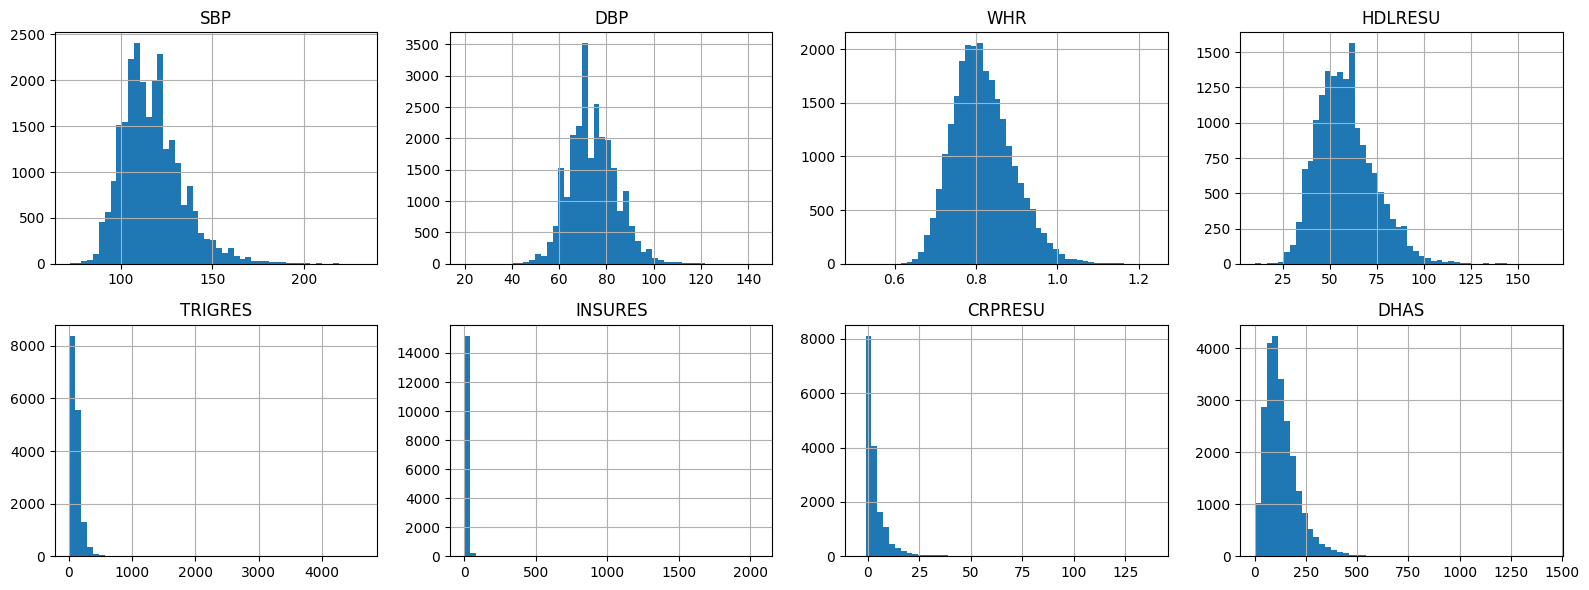

In [72]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, var in zip(axes.flat, al_vars):
    df[var].hist(bins=50, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.show()


In [73]:
df["log_TRIG"]  = np.log(df["TRIGRES"])
df["log_INSUR"] = np.log(df["INSURES"])
df["log_CRP"]   = np.log(df["CRPRESU"] + 1)  # +1 offset to handle zeros
df["log_DHAS"]  = np.log(df["DHAS"])

al_vars_transformed = ["SBP", "DBP", "WHR", "HDLRESU", "log_TRIG", "log_INSUR", "log_CRP", "log_DHAS"]

print("Skewness (after log transform):")
print(df[al_vars_transformed].skew().sort_values(ascending=False))


Skewness (after log transform):
log_INSUR    1.020247
SBP          1.019384
log_CRP      0.809547
log_TRIG     0.752315
HDLRESU      0.686544
WHR          0.518692
DBP          0.407525
log_DHAS    -0.738919
dtype: float64


C:\Users\gerga\python3.10\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


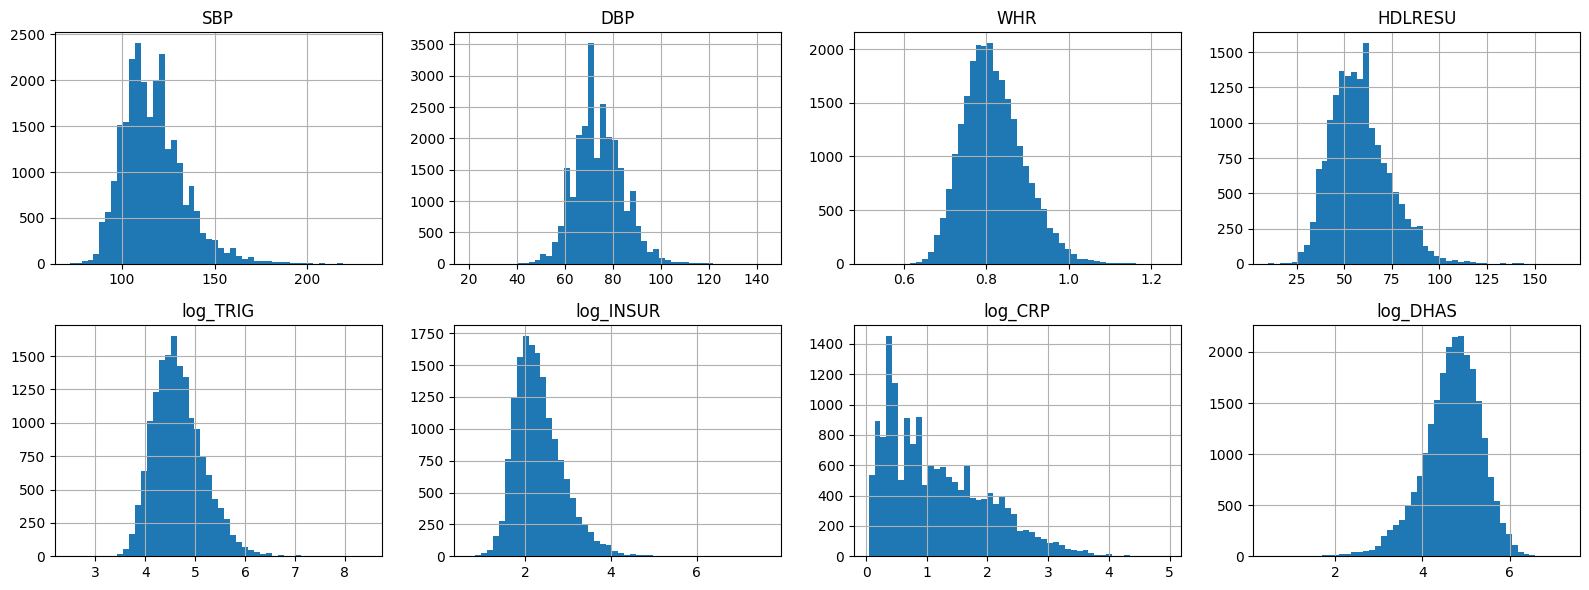

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, var in zip(axes.flat, al_vars_transformed):
    df[var].hist(bins=50, ax=ax)
    ax.set_title(var)
plt.tight_layout()
plt.show()


## 5. Build analytic sample

Filter before deriving cutoffs so thresholds reflect the analytic population.

In [75]:
df_model = df[
    df["sleep_quality"].notna() &
    df["AL_score"].notna() if "AL_score" in df.columns else df["sleep_quality"].notna()
].copy()

# Exclude post-surgical menopause + unknown statuses (STATUS 1 and 6-8)
df_model = df_model[~df_model["STATUS"].isin([1, 6, 7, 8])]
print("After STATUS filter:", df_model["STATUS"].value_counts().sort_index())


After STATUS filter: STATUS
2.0     7512
3.0     1981
4.0    10130
5.0     3647
Name: count, dtype: int64


In [76]:
# Require >=2 sleep observations per participant
valid_ids = df_model.groupby("SWANID")["sleep_quality"].count() >= 2
df_model = df_model[df_model["SWANID"].isin(valid_ids[valid_ids].index)]
print("After repeated-obs filter:", df_model.shape)


After repeated-obs filter: (23089, 2110)


## 6. Baseline AL score

Cutoffs derived from the analytic sample at visit 0.

In [77]:
high_risk_high = ["SBP", "DBP", "WHR", "log_TRIG", "log_INSUR", "log_CRP"]
high_risk_low  = ["HDLRESU", "log_DHAS"]

# Build baseline from analytic sample
baseline_al = df_model[df_model["VISIT"] == 0][["SWANID"] + al_vars_transformed].copy()

print("Baseline shape:", baseline_al.shape)
print("Missingness:")
print(baseline_al[al_vars_transformed].isna().mean().sort_values(ascending=False))


Baseline shape: (2970, 9)
Missingness:
log_INSUR    0.054882
log_TRIG     0.054545
log_CRP      0.017172
WHR          0.014478
HDLRESU      0.007071
log_DHAS     0.003030
DBP          0.002694
SBP          0.002357
dtype: float64


In [78]:
cutoffs = {}

for var in high_risk_high:
    cutoff = baseline_al[var].quantile(0.75)
    cutoffs[var] = {"direction": "upper quartile", "cutoff": cutoff}
    baseline_al[f"{var}_risk"] = np.where(
        baseline_al[var].notna(),
        (baseline_al[var] >= cutoff).astype(int),
        np.nan
    )

for var in high_risk_low:
    cutoff = baseline_al[var].quantile(0.25)
    cutoffs[var] = {"direction": "lower quartile", "cutoff": cutoff}
    baseline_al[f"{var}_risk"] = np.where(
        baseline_al[var].notna(),
        (baseline_al[var] <= cutoff).astype(int),
        np.nan
    )

cutoffs


{'SBP': {'direction': 'upper quartile', 'cutoff': 126.0},
 'DBP': {'direction': 'upper quartile', 'cutoff': 81.33333333333333},
 'WHR': {'direction': 'upper quartile', 'cutoff': 0.8469179940058519},
 'log_TRIG': {'direction': 'upper quartile', 'cutoff': 4.859812404361672},
 'log_INSUR': {'direction': 'upper quartile', 'cutoff': 2.5494451709255714},
 'log_CRP': {'direction': 'upper quartile', 'cutoff': 1.6863989535702288},
 'HDLRESU': {'direction': 'lower quartile', 'cutoff': 46.0},
 'log_DHAS': {'direction': 'lower quartile', 'cutoff': 4.330733340286331}}

In [79]:
risk_cols = [f"{var}_risk" for var in al_vars_transformed]

baseline_al["n_AL_markers_available"] = baseline_al[al_vars_transformed].notna().sum(axis=1)
baseline_al["AL_score_raw"] = baseline_al[risk_cols].sum(axis=1, skipna=True)
baseline_al["AL_score"] = np.where(
    baseline_al["n_AL_markers_available"] >= 6,  # Require at least 6 out of 8 biomarkers
    baseline_al["AL_score_raw"],
    np.nan
)

print(baseline_al["AL_score"].describe())
print("\nAL score counts:")
print(baseline_al["AL_score"].value_counts(dropna=False).sort_index())


count    2942.000000
mean        1.996601
std         1.853341
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: AL_score, dtype: float64

AL score counts:
AL_score
0.0    789
1.0    655
2.0    467
3.0    405
4.0    272
5.0    199
6.0    105
7.0     43
8.0      7
NaN     28
Name: count, dtype: int64


## 7. Merge baseline AL score into analytic sample

In [80]:
df_model = df_model.merge(
    baseline_al[["SWANID", "AL_score", "n_AL_markers_available"]],
    on="SWANID",
    how="left"
)
print(df_model.shape)
print(df_model[["SWANID", "VISIT", "sleep_quality", "AL_score"]].head(20))


(23089, 2112)
    SWANID  VISIT  sleep_quality  AL_score
0    10056      0            2.0       1.0
1    10092      0            2.0       3.0
2    10126      0            2.0       1.0
3    10153      0            2.0       5.0
4    10196      0            2.0       0.0
5    10245      0            1.0       0.0
6    10464      0            2.0       2.0
7    10484      0            1.0       3.0
8    10514      0            2.0       2.0
9    10522      0            3.0       0.0
10   10532      0            2.0       4.0
11   10550      0            3.0       6.0
12   10604      0            2.0       0.0
13   10629      0            2.0       2.0
14   10630      0            3.0       1.0
15   10694      0            2.0       1.0
16   10747      0            2.0       5.0
17   10757      0            1.0       4.0
18   10801      0            4.0       1.0
19   10879      0            2.0       3.0


In [81]:
# Drop rows missing AL_score now that it has been merged in
df_model = df_model[df_model["AL_score"].notna()].copy()
print("After AL_score filter:", df_model.shape)


After AL_score filter: (22772, 2112)


## 8. Add covariates

### Menopausal stage

In [82]:
mapping = {5: 0, 4: 1, 3: 2, 2: 3}  # 0=pre, 1=early peri, 2=late peri, 3=post
df_model["meno_stage"] = df_model["STATUS"].map(mapping)


### Baseline age

In [83]:
baseline_age = (
    df_model[df_model["VISIT"] == 0][["SWANID", "AGE"]]
    .rename(columns={"AGE": "AGE_baseline"})
)
df_model = df_model.merge(baseline_age, on="SWANID", how="left")


### CES-D score (depression; sleep item excluded)

In [84]:
cesd_negative_vars = [
    "BOTHER", "APPETIT", "BLUES", "DEPRESS", "EFFORT", "FAILURE",
    "FEARFUL", "TALKLES", "LONELY", "UNFRNDL", "CRYING", "SAD",
    "DISLIKE", "KEEPMIN", "GETGOIN"
]  ##Excluding sleep var

cesd_positive_vars = ["GOOD", "HOPEFUL", "HAPPY", "ENJOY"]

for col in cesd_negative_vars:
    df_model[col + "_score"] = df_model[col] - 1 ##Adding -1 to score to achieve the CESD scoring 

for col in cesd_positive_vars:
    df_model[col + "_score"] = 4 - df_model[col]  ##4-score to achieve the CESD scoring 

cesd_score_cols = [col + "_score" for col in cesd_negative_vars + cesd_positive_vars]
df_model["CESD_score"] = df_model[cesd_score_cols].sum(axis=1)

print(df_model["CESD_score"].describe())
print()
print(df_model[cesd_positive_vars].describe())


count    22772.000000
mean         7.941858
std          8.328730
min          0.000000
25%          2.000000
50%          5.000000
75%         11.000000
max         55.000000
Name: CESD_score, dtype: float64

               GOOD       HOPEFUL         HAPPY         ENJOY
count  22546.000000  22557.000000  22569.000000  22569.000000
mean       3.655504      3.468724      3.349284      3.493819
std        0.740888      0.822551      0.854425      0.809631
min        1.000000      1.000000      1.000000      1.000000
25%        4.000000      3.000000      3.000000      3.000000
50%        4.000000      4.000000      4.000000      4.000000
75%        4.000000      4.000000      4.000000      4.000000
max        4.000000      4.000000      4.000000      4.000000


### Prescription medications (binary)
##### The NERVS1 variable, which reflected on any prescribed nervous-system medications, was selected over SLEEP1, which only looked at over-the-counter sleep medicine

In [85]:
df_model["presc_med"] = df_model["NERVS1"].map({2: 1, 1: 0})


### Vasomotor symptoms (binary)

In [86]:
df_model["VMS_binary"] = (
    (df_model["HOTFLAS"] >= 3) | (df_model["NITESWE"] >= 3)
).astype(int)


## 9. Correlation checks

In [87]:
print("VISIT / DHAS / sleep_quality:")
print(df_model[["VISIT", "DHAS", "sleep_quality"]].corr(method="spearman"))
print()
print("VISIT / AGE / menopause status / sleep_quality:")
print(df_model[["VISIT", "AGE", "STATUS", "sleep_quality"]].corr(method="spearman"))
print()
print("Sleep sub-items:")
print(df_model[["TRBLSLE", "WAKEUP", "WAKEARL", "sleep_quality"]].corr(method="spearman"))
print()
print("CES-D / nervous system meds / OTC sleep meds:")
print(df_model[["CESD_score", "NERVS1", "SLEEP1"]].corr(method="spearman"))
print()
print("CES-D / nervous system meds / Sleep Quality:")
print(df_model[["CESD_score", "NERVS1", "sleep_quality"]].corr(method="spearman"))


VISIT / DHAS / sleep_quality:
                  VISIT      DHAS  sleep_quality
VISIT          1.000000 -0.024521      -0.071082
DHAS          -0.024521  1.000000      -0.029950
sleep_quality -0.071082 -0.029950       1.000000

VISIT / AGE / menopause status / sleep_quality:
                  VISIT       AGE    STATUS  sleep_quality
VISIT          1.000000  0.775746 -0.680421      -0.071082
AGE            0.775746  1.000000 -0.725940      -0.064534
STATUS        -0.680421 -0.725940  1.000000       0.013015
sleep_quality -0.071082 -0.064534  0.013015       1.000000

Sleep sub-items:
                TRBLSLE    WAKEUP   WAKEARL  sleep_quality
TRBLSLE        1.000000  0.414950  0.448580       0.497147
WAKEUP         0.414950  1.000000  0.481203       0.507654
WAKEARL        0.448580  0.481203  1.000000       0.480465
sleep_quality  0.497147  0.507654  0.480465       1.000000

CES-D / nervous system meds / OTC sleep meds:
            CESD_score    NERVS1    SLEEP1
CESD_score     1.00000  0.1

## 10. VIF collinearity check

In [99]:
predictors_df = df_model[["AL_score", "AGE_baseline", "CESD_score", "presc_med",
                           "VMS_binary", "meno_stage", "RACE", "INCOME"]].dropna()

predictors_dummies = pd.get_dummies(predictors_df,
                                     columns=[ "meno_stage", "RACE", "INCOME"],
                                     drop_first=True)

X = sm.add_constant(predictors_dummies.astype(float))

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)


          variable         VIF
0            const  349.914063
1         AL_score    1.158507
2     AGE_baseline    1.181844
3       CESD_score    1.135492
4        presc_med    1.084894
5       VMS_binary    1.081202
6   meno_stage_1.0    3.212915
7   meno_stage_2.0    1.944109
8   meno_stage_3.0    3.467390
9           RACE_2    1.350398
10          RACE_3    1.403532
11          RACE_4    1.650319
12          RACE_5    1.201205
13      INCOME_2.0    2.951920
14      INCOME_3.0    3.324256
15      INCOME_4.0    3.436256


In [103]:
predictors_df = df_model[["log_DHAS", "AGE_baseline", "CESD_score", "presc_med",
                           "VMS_binary", "meno_stage", "RACE", "INCOME"]].dropna()

predictors_dummies = pd.get_dummies(predictors_df,
                                     columns=["meno_stage", "RACE", "INCOME"],
                                     drop_first=True)

X = sm.add_constant(predictors_dummies.astype(float))

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)

          variable         VIF
0            const  420.299226
1         log_DHAS    1.065517
2     AGE_baseline    1.174129
3       CESD_score    1.129814
4        presc_med    1.087698
5       VMS_binary    1.080041
6   meno_stage_1.0    3.144961
7   meno_stage_2.0    1.916228
8   meno_stage_3.0    3.406149
9           RACE_2    1.355142
10          RACE_3    1.377890
11          RACE_4    1.616552
12          RACE_5    1.172890
13      INCOME_2.0    2.975723
14      INCOME_3.0    3.351355
15      INCOME_4.0    3.446731


In [102]:
predictors_df = df_model[["AL_score", "AGE", "CESD_score", "presc_med",
                           "VMS_binary", "meno_stage", "RACE", "INCOME"]].dropna()

predictors_dummies = pd.get_dummies(predictors_df,
                                     columns=["meno_stage", "RACE", "INCOME"],
                                     drop_first=True)

X = sm.add_constant(predictors_dummies.astype(float))

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)


          variable         VIF
0            const  305.632538
1         AL_score    1.149249
2              AGE    2.020519
3       CESD_score    1.138855
4        presc_med    1.082389
5       VMS_binary    1.081097
6   meno_stage_1.0    3.276027
7   meno_stage_2.0    2.104256
8   meno_stage_3.0    4.695948
9           RACE_2    1.349854
10          RACE_3    1.403068
11          RACE_4    1.648757
12          RACE_5    1.204562
13      INCOME_2.0    2.950732
14      INCOME_3.0    3.322385
15      INCOME_4.0    3.451252


## 11. Inter-personal availability

In [54]:
print("Observations per participant:")
print(df_model.groupby("SWANID").size().describe())
print()
print("Sleep quality observations per participant:")
print(df_model.groupby("SWANID")["sleep_quality"].apply(lambda x: x.notna().sum()).describe())
print()
print("DHAS observations per participant:")
print(df_model.groupby("SWANID")["DHAS"].apply(lambda x: x.notna().sum()).describe())
print()
print("Co-observed sleep + DHAS per participant:")
print(df_model.groupby("SWANID").apply(
    lambda x: ((x["sleep_quality"].notna()) & (x["DHAS"].notna())).sum()
).describe())


Observations per participant:
count    2942.000000
mean        7.740313
std         2.898580
min         2.000000
25%         6.000000
50%         9.000000
75%        10.000000
max        11.000000
dtype: float64

Sleep quality observations per participant:
count    2942.000000
mean        7.740313
std         2.898580
min         2.000000
25%         6.000000
50%         9.000000
75%        10.000000
max        11.000000
Name: sleep_quality, dtype: float64

DHAS observations per participant:
count    2942.000000
mean        7.018355
std         3.083503
min         1.000000
25%         4.000000
50%         8.000000
75%        10.000000
max        11.000000
Name: DHAS, dtype: float64

Co-observed sleep + DHAS per participant:
count    2942.000000
mean        7.018355
std         3.083503
min         1.000000
25%         4.000000
50%         8.000000
75%        10.000000
max        11.000000
dtype: float64


C:\Users\gerga\AppData\Local\Temp\ipykernel_23224\183729311.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df_model.groupby("SWANID").apply(


In [90]:
df_model.groupby("AL_score")["sleep_quality"].mean()  # Inspect trajectory


AL_score
0.0    1.970902
1.0    2.043327
2.0    2.078073
3.0    2.080302
4.0    2.132713
5.0    2.108617
6.0    2.125668
7.0    2.228571
8.0    2.377049
Name: sleep_quality, dtype: float64

## 12. Longitudinal AL score (using baseline-derived cutoffs)

In [91]:
al_long = df_model[["SWANID", "VISIT"] + al_vars_transformed].copy()

for var in high_risk_high:
    cutoff = cutoffs[var]["cutoff"]
    al_long[f"{var}_risk"] = np.where(
        al_long[var].notna(),
        (al_long[var] >= cutoff).astype(int),
        np.nan
    )

for var in high_risk_low:
    cutoff = cutoffs[var]["cutoff"]
    al_long[f"{var}_risk"] = np.where(
        al_long[var].notna(),
        (al_long[var] <= cutoff).astype(int),
        np.nan
    )

risk_cols_long = [f"{var}_risk" for var in al_vars_transformed]

al_long["n_AL_markers_available"] = al_long[al_vars_transformed].notna().sum(axis=1)
al_long["AL_score_raw"]           = al_long[risk_cols_long].sum(axis=1, skipna=True)
al_long["AL_score_long"]          = np.where(
    al_long["n_AL_markers_available"] >= 6,
    al_long["AL_score_raw"],
    np.nan
)

print(al_long["AL_score_long"].describe())


count    14007.000000
mean         2.077533
std          1.859398
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: AL_score_long, dtype: float64


In [100]:
predictors_df = df_model[["AL_score_long", "AGE_baseline", "CESD_score", "presc_med",
                           "VMS_binary", "meno_stage", "RACE", "INCOME"]].dropna()

predictors_dummies = pd.get_dummies(predictors_df,
                                     columns=["meno_stage", "RACE", "INCOME"],
                                     drop_first=True)

X = sm.add_constant(predictors_dummies.astype(float))

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)

          variable         VIF
0            const  364.074900
1    AL_score_long    1.156966
2     AGE_baseline    1.249260
3       CESD_score    1.138571
4        presc_med    1.077121
5       VMS_binary    1.097589
6   meno_stage_1.0    2.746295
7   meno_stage_2.0    1.828950
8   meno_stage_3.0    2.913444
9           RACE_2    1.365104
10          RACE_3    1.414749
11          RACE_4    1.671330
12          RACE_5    1.196582
13      INCOME_2.0    2.952235
14      INCOME_3.0    3.424592
15      INCOME_4.0    3.337477


## 13. Biomarker availability by visit

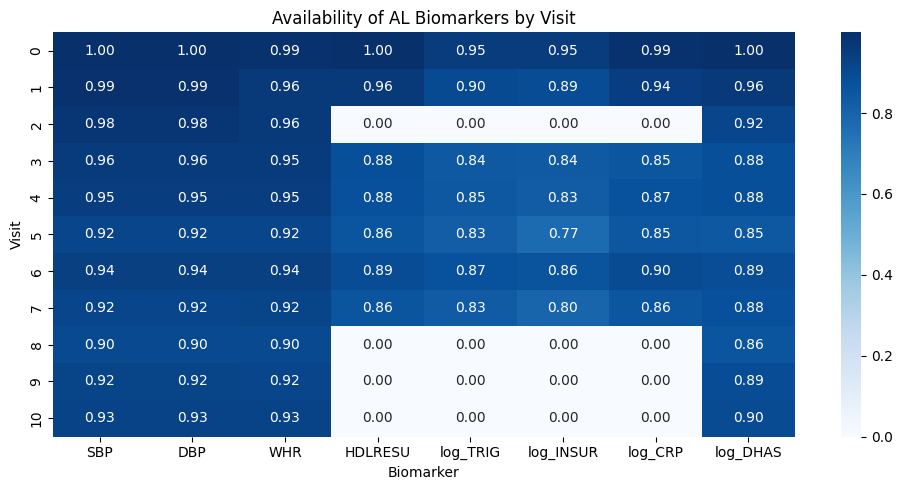

In [92]:
marker_availability = (
    df_model.groupby("VISIT")[al_vars_transformed]
    .apply(lambda x: x.notna().mean())
)

plt.figure(figsize=(10, 5))
sns.heatmap(marker_availability, annot=True, fmt=".2f", cmap="Blues")
plt.title("Availability of AL Biomarkers by Visit")
plt.ylabel("Visit")
plt.xlabel("Biomarker")
plt.tight_layout()
plt.show()


## 14. Reduced longitudinal AL score (sensitivity analysis)

Drops the 4 markers systematically missing at visits 2, 8, 9, 10.

In [93]:
al_vars_reduced       = [v for v in al_vars_transformed if v not in ["log_INSUR", "log_CRP", "HDLRESU", "log_TRIG"]]
high_risk_high_reduced = [v for v in high_risk_high if v in al_vars_reduced]
high_risk_low_reduced  = [v for v in high_risk_low  if v in al_vars_reduced]

for var in high_risk_high_reduced:
    cutoff = cutoffs[var]["cutoff"]
    al_long[f"{var}_risk_reduced"] = np.where(
        al_long[var].notna(),
        (al_long[var] >= cutoff).astype(int),
        np.nan
    )

for var in high_risk_low_reduced:
    cutoff = cutoffs[var]["cutoff"]
    al_long[f"{var}_risk_reduced"] = np.where(
        al_long[var].notna(),
        (al_long[var] <= cutoff).astype(int),
        np.nan
    )

risk_cols_reduced = [f"{var}_risk_reduced" for var in al_vars_reduced]

al_long["n_AL_markers_reduced"] = al_long[al_vars_reduced].notna().sum(axis=1)
al_long["AL_score_reduced_raw"] = al_long[risk_cols_reduced].sum(axis=1, skipna=True)

# Threshold proportional to full score: 6/8 = 75%, so 3/4
al_long["AL_score_reduced"] = np.where(
    al_long["n_AL_markers_reduced"] >= 3,
    al_long["AL_score_reduced_raw"],
    np.nan
)

print(al_long["AL_score_reduced"].describe())


count    21654.000000
mean         1.023552
std          1.059579
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: AL_score_reduced, dtype: float64


In [101]:
predictors_df = df_model[["AL_score_reduced", "AGE_baseline", "CESD_score", "presc_med",
                           "VMS_binary", "meno_stage", "RACE", "INCOME"]].dropna()

predictors_dummies = pd.get_dummies(predictors_df,
                                     columns=["meno_stage", "RACE", "INCOME"],
                                     drop_first=True)

X = sm.add_constant(predictors_dummies.astype(float))

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif)

            variable         VIF
0              const  349.956103
1   AL_score_reduced    1.157819
2       AGE_baseline    1.184600
3         CESD_score    1.138804
4          presc_med    1.088652
5         VMS_binary    1.084297
6     meno_stage_1.0    3.166420
7     meno_stage_2.0    1.935493
8     meno_stage_3.0    3.415394
9             RACE_2    1.357984
10            RACE_3    1.393742
11            RACE_4    1.690633
12            RACE_5    1.194943
13        INCOME_2.0    2.982033
14        INCOME_3.0    3.374740
15        INCOME_4.0    3.464647


## 15. Merge longitudinal AL scores into analytic sample

In [94]:
df_model = df_model.merge(
    al_long[["SWANID", "VISIT", "AL_score_long", "AL_score_reduced"]],
    on=["SWANID", "VISIT"],
    how="left"
)

print(df_model.shape)
print(df_model[["SWANID", "VISIT", "AL_score", "AL_score_long", "AL_score_reduced"]].head(20))


(22772, 2138)
    SWANID  VISIT  AL_score  AL_score_long  AL_score_reduced
0    10056      0       1.0            1.0               1.0
1    10092      0       3.0            3.0               0.0
2    10126      0       1.0            1.0               0.0
3    10153      0       5.0            5.0               2.0
4    10196      0       0.0            0.0               0.0
5    10245      0       0.0            0.0               0.0
6    10464      0       2.0            2.0               0.0
7    10484      0       3.0            3.0               3.0
8    10514      0       2.0            2.0               0.0
9    10522      0       0.0            0.0               0.0
10   10532      0       4.0            4.0               2.0
11   10550      0       6.0            6.0               3.0
12   10604      0       0.0            0.0               0.0
13   10629      0       2.0            2.0               1.0
14   10630      0       1.0            1.0               0.0
15   10694

## 16. Save analysis dataset

In [34]:
df_model.to_csv("swan_analysis_ready_v3.csv", index=False)

## 17. Missing data mechanism - Little's MCAR test


In [25]:
!pip install pyampute --break-system-packages

from pyampute.exploration.mcar_statistical_tests import MCARTest


[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: C:\Users\gerga\python3.10\python.exe -m pip install --upgrade pip


In [62]:
## Test on the model variables only
mcar_vars = ["sleep_quality", "AL_score", "CESD_score", "AGE_baseline",
             "meno_stage", "RACE", "INCOME", "presc_med", "VMS_binary",
             "log_DHAS", "SBP", "DBP", "WHR", "HDLRESU", 
             "log_TRIG", "log_INSUR", "log_CRP"]

test_data = df_model[mcar_vars].copy()

mcar = MCARTest(method="little")
p_value = mcar.little_mcar_test(test_data)
print(f"Little's MCAR test p-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Data is NOT MCAR (p < .05) — missingness is systematic.")
    print("MAR or MNAR cannot be ruled out. Multiple imputation recommended.")
else:
    print("Result: No evidence against MCAR (p >= .05).")

Little's MCAR test p-value: 0.000000

Result: Data is NOT MCAR (p < .05) — missingness is systematic.
MAR or MNAR cannot be ruled out. Multiple imputation recommended.


In [63]:
## 17. Sample demographics of the analytic dataset

# Use one row per participant (baseline visit) for person-level characteristics
df_baseline = df_model[df_model["VISIT"] == 0].copy()

n_participants = df_model["SWANID"].nunique()
n_observations = len(df_model)
print(f"Analytic sample: {n_participants} participants, {n_observations} observations\n")

# --- Race/Ethnicity ---
race_labels = {1: "Black/African American", 2: "Chinese/Chinese American",
               3: "Japanese/Japanese American", 4: "Caucasian/White Non-Hispanic",
               5: "Hispanic"}

race_counts = df_baseline["RACE"].map(race_labels).value_counts()
race_pct    = (race_counts / n_participants * 100).round(1)
race_table  = pd.DataFrame({"Participants (n)": race_counts,
                             "Percentage (%)":   race_pct})
print("TABLE I — Racial and Ethnic Distribution")
print(race_table.to_string())
print()

# --- Age at baseline ---
print("TABLE II — Age at Baseline")
print(df_baseline["AGE"].describe()[["mean","std","min","max"]].round(2))
print()


# --- Income ---
income_labels = {1: "<$20k", 2: "$20–49k", 3: "$50–99k", 4: "$100k+"}

income_counts = df_baseline["INCOME"].map(income_labels).value_counts()
income_pct    = (income_counts / n_participants * 100).round(1)
income_table  = pd.DataFrame({"Participants (n)": income_counts,
                               "Percentage (%)":   income_pct})
print("TABLE IV — Income Distribution")
print(income_table.to_string())
print()

# --- Attendance and age by visit ---
visit_stats = df_model.groupby("VISIT").agg(
    N        = ("SWANID", "count"),
    Age_Mean = ("AGE",    "mean")
).round(2)
visit_stats["Attendance (%)"] = (visit_stats["N"] / n_participants * 100).round(1)
print("TABLE V — Participant Attendance and Age Distribution Across Visits")
print(visit_stats[["N", "Attendance (%)", "Age_Mean"]].to_string())

Analytic sample: 2942 participants, 22772 observations

TABLE I — Racial and Ethnic Distribution
                              Participants (n)  Percentage (%)
RACE                                                          
Caucasian/White Non-Hispanic              1398            47.5
Black/African American                     814            27.7
Japanese/Japanese American                 272             9.2
Chinese/Chinese American                   237             8.1
Hispanic                                   221             7.5

TABLE II — Age at Baseline
mean    45.85
std      2.69
min     42.00
max     53.00
Name: AGE, dtype: float64

TABLE IV — Income Distribution
         Participants (n)  Percentage (%)
INCOME                                   
$50–99k              1059            36.0
$20–49k               966            32.8
$100k+                437            14.9
<$20k                 407            13.8

TABLE V — Participant Attendance and Age Distribution Across Visits

In [64]:

# --- Menopausal stage distribution (person-visits) ---
meno_labels = {0: "Pre-menopausal", 1: "Early Perimenopausal",
               2: "Late Perimenopausal", 3: "Post-menopausal"}

meno_counts = df_model["meno_stage"].map(meno_labels).value_counts().sort_index()
meno_pct    = (meno_counts / n_observations * 100).round(1)
meno_table  = pd.DataFrame({"Observations (n)": meno_counts,
                             "Percentage (%)":   meno_pct})
print("TABLE VI — Menopausal Stage Distribution (person-visits)")
print(meno_table.to_string())
print()

# --- Sleep quality distribution (person-visits) ---
sleep_labels = {1: "Very good", 2: "Fairly good",
                3: "Fairly bad", 4: "Very bad"}

sleep_counts = df_model["sleep_quality"].map(sleep_labels).value_counts().sort_index()
sleep_pct    = (sleep_counts / n_observations * 100).round(1)
sleep_table  = pd.DataFrame({"Observations (n)": sleep_counts,
                              "Percentage (%)":   sleep_pct})
print("TABLE VII — Sleep Quality Distribution (person-visits)")
print(sleep_table.to_string())
print()

# --- VMS binary (person-visits) ---
vms_labels = {0: "No VMS", 1: "VMS present"}

vms_counts = df_model["VMS_binary"].map(vms_labels).value_counts().sort_index()
vms_pct    = (vms_counts / n_observations * 100).round(1)
vms_table  = pd.DataFrame({"Observations (n)": vms_counts,
                            "Percentage (%)":   vms_pct})
print("TABLE VIII — Vasomotor Symptom Presence (person-visits)")
print(vms_table.to_string())
print()

# --- Prescription medication (person-visits) ---
presc_counts = df_model["presc_med"].value_counts().sort_index()
presc_labels = {0: "No prescription medication", 1: "Prescription medication use"}
presc_counts.index = presc_counts.index.map(presc_labels)
presc_pct    = (presc_counts / n_observations * 100).round(1)
presc_table  = pd.DataFrame({"Observations (n)": presc_counts,
                              "Percentage (%)":   presc_pct})
print("TABLE IX — Prescription Medication Use (person-visits)")
print(presc_table.to_string())
print()

# --- Summary: unique participants per category for VMS and presc_med ---
print("Unique participants with at least one VMS-positive visit:")
print(df_model[df_model["VMS_binary"] == 1]["SWANID"].nunique())
print()
print("Unique participants with at least one prescription medication visit:")
print(df_model[df_model["presc_med"] == 1]["SWANID"].nunique())

TABLE VI — Menopausal Stage Distribution (person-visits)
                      Observations (n)  Percentage (%)
meno_stage                                            
Early Perimenopausal              9831            43.2
Late Perimenopausal               1955             8.6
Post-menopausal                   7422            32.6
Pre-menopausal                    3444            15.1

TABLE VII — Sleep Quality Distribution (person-visits)
               Observations (n)  Percentage (%)
sleep_quality                                  
Fairly bad                 3955            17.4
Fairly good               13553            59.5
Very bad                    820             3.6
Very good                  4444            19.5

TABLE VIII — Vasomotor Symptom Presence (person-visits)
             Observations (n)  Percentage (%)
VMS_binary                                   
No VMS                  18236            80.1
VMS present              4536            19.9

TABLE IX — Prescription Med